# DICOM-based CSF PC-MRI + DL Segmentation + Flow Visualization

This notebook reproduces the logic of `compute_biomarkers_from_dicom.py` but in an **interactive** way:

- Reads a **DICOMDIR** specified in a YAML config file (same as the script).
- Automatically selects the PC-MRI series (if `series_number` is `null`) using the description filter.
- Runs the **DL model** in AUTO mode to predict the CSF ROI.
- Computes **CSF flow biomarkers** using `compute_flow_and_stroke_volume`.
- Visualizes:
  - The **flow curve** over the cardiac cycle.
  - **Magnitude** and **phase** images overlaid with the predicted mask.

> 🔧 Place this notebook in the same directory as your Python modules
> (`preprocess_dicom.py`, `csf_flow.py`, `src/models/unet2d.py`, etc.) so imports work.


In [1]:
import numpy as np
from pathlib import Path
import re

import yaml
import numpy as np
import matplotlib.pyplot as plt

import torch

# Project modules (must be importable from this notebook's directory)
from preprocess_dicom import inventory_dicomdir, load_series_from_dicomdir, embed_mask_in_image, _norm01 as _norm01_img
from csf_flow import compute_flow_and_stroke_volume
from src.models.unet2d import UNet2D
try:
    from src.utils.misc import load_ckpt
except Exception:
    load_ckpt = None

from src.utils.temporal_features import (
    temporal_std,
    temporal_tv,
    dft_bandpower_excl_dc,
    dft_magnitudes_bins,
)

# Make plots appear inline
%matplotlib inline

In [2]:
# =========================
# Helper functions (adapted from compute_biomarkers_from_dicom.py)
# =========================

def _phase01_to_unit(phase_stack_01: np.ndarray) -> np.ndarray:
    # Convert phase from [0,1] to [-1,1] as expected by the flow physics.
    return phase_stack_01 * 2.0 - 1.0


def _extract_trigger_time(ds):
    tt = getattr(ds, 'TriggerTime', None)
    if tt is not None:
        try:
            return float(tt)
        except Exception:
            pass
    elem = ds.get((0x0018, 0x1060), None)  # Trigger Time
    if elem is not None:
        try:
            return float(str(elem.value).replace(',', '\\').split('\\')[0])
        except Exception:
            return None
    return None


def _extract_instance_number(ds):
    inst = getattr(ds, 'InstanceNumber', None)
    try:
        return int(inst) if inst is not None else None
    except Exception:
        return None


def _sort_temporally(datasets):
    def key(ds):
        tt = _extract_trigger_time(ds)
        inst = _extract_instance_number(ds)
        return (float(tt) if tt is not None else float('inf'),
                int(inst) if inst is not None else 1_000_000)
    return sorted(datasets, key=key)


def _align_phase_to_mag(phase_ds, mag_ds):
    '''Align 64 PHASE frames to 32 MAG frames by time, as in the script.'''
    mag_times = [(_extract_trigger_time(ds), i) for i, ds in enumerate(mag_ds)]
    ph_times  = [(_extract_trigger_time(ds), i) for i, ds in enumerate(phase_ds)]

    have_times = all(t is not None for t, _ in mag_times) and all(t is not None for t, _ in ph_times)

    if have_times:
        from collections import defaultdict

        def rkey(t): return int(round(t))

        phase_by_time = defaultdict(list)
        for t, i in ph_times:
            phase_by_time[rkey(t)].append(i)

        selected_idx = []
        for t_mag, _ in mag_times:
            rk = rkey(t_mag)
            candidates = phase_by_time.get(rk, [])
            if not candidates:
                diffs = [(abs(t_mag - t_ph), i) for (t_ph, i) in ph_times]
                diffs.sort()
                cand = diffs[0][1]
                selected_idx.append(cand)
            elif len(candidates) == 1:
                selected_idx.append(candidates[0])
            else:
                stds = []
                for ci in candidates:
                    arr = phase_ds[ci].pixel_array.astype(np.float32)
                    stds.append((float(arr.std()), ci))
                stds.sort(reverse=True)
                selected_idx.append(stds[0][1])

        seen = set()
        uniq = []
        for i in selected_idx:
            if i not in seen:
                uniq.append(i)
                seen.add(i)
        if len(uniq) < 32:
            remaining = [i for _, i in ph_times if i not in seen]
            uniq.extend(remaining[: 32 - len(uniq)])

        aligned_phase = [phase_ds[i] for i in uniq[:32]]
        print(f"[align] used times: TriggerTime-based (unique {len(set(uniq[:32]))}/32).")
        return aligned_phase

    # Fallback: no times → try even vs odd slices
    even_idx = list(range(0, len(phase_ds), 2))[:32]
    odd_idx  = list(range(1, len(phase_ds), 2))[:32]

    def mean_std(idxs):
        vals = []
        for i in idxs:
            arr = phase_ds[i].pixel_array.astype(np.float32)
            vals.append(float(arr.std()))
        return float(np.mean(vals)) if vals else 0.0

    even_std = mean_std(even_idx)
    odd_std  = mean_std(odd_idx)
    choice = 'even' if even_std >= odd_std else 'odd'
    idxs = even_idx if choice == 'even' else odd_idx
    print(f"[align] no TriggerTime: chose {choice} indices (mean std {max(even_std, odd_std):.4f}).")
    return [phase_ds[i] for i in idxs]


def _series_to_full_stacks_RAW_and_01(split):
    '''Return RAW stacks (phase_raw, mag_raw) and [0,1] stacks (phase_01, mag_01).'''
    phase_all = _sort_temporally(split.phase)
    mag_all   = _sort_temporally(split.mag)

    n_phase = len(phase_all)
    n_mag   = len(mag_all)
    print(f"[series] phase frames={n_phase} | mag frames={n_mag}")

    if n_mag < 32 or n_phase < 32:
        raise RuntimeError(f"Need at least 32 PHASE + 32 MAG. Found {n_phase} / {n_mag}. Pick the correct PC-MRI series.")

    if n_phase == 64 and n_mag >= 32:
        mag_sel   = mag_all[:32]
        phase_sel = _align_phase_to_mag(phase_all, mag_sel)
    else:
        phase_sel = phase_all[:32]
        mag_sel   = mag_all[:32]

    phase_raw = np.stack([ds.pixel_array.astype(np.float32) for ds in phase_sel], axis=0)
    mag_raw   = np.stack([ds.pixel_array.astype(np.float32) for ds in mag_sel],   axis=0)

    phase_01 = np.stack([_norm01_img(ds.pixel_array.astype(np.float32)) for ds in phase_sel], axis=0)
    mag_01   = np.stack([_norm01_img(ds.pixel_array.astype(np.float32)) for ds in mag_sel],   axis=0)
    return phase_raw, mag_raw, phase_01, mag_01


def _center_crop(arr: np.ndarray, crop: int) -> np.ndarray:
    if arr.ndim == 3:
        T, H, W = arr.shape
        y0 = (H - crop) // 2
        x0 = (W - crop) // 2
        return arr[:, y0:y0+crop, x0:x0+crop]
    elif arr.ndim == 2:
        H, W = arr.shape
        y0 = (H - crop) // 2
        x0 = (W - crop) // 2
        return arr[y0:y0+crop, x0:x0+crop]
    else:
        raise ValueError('Array must be 2-D or 3-D')


def _pad_crop_to_size(mask_crop: np.ndarray, H: int, W: int, crop: int) -> np.ndarray:
    y0 = (H - crop) // 2
    x0 = (W - crop) // 2
    out = np.zeros((H, W), dtype=mask_crop.dtype)
    out[y0:y0+crop, x0:x0+crop] = mask_crop
    return out


def _zscore_per_sample(x: np.ndarray, eps=1e-6) -> np.ndarray:
    mu = float(x.mean())
    sd = float(x.std())
    return (x - mu) / (sd + eps)


def _first_pc(vol: np.ndarray) -> np.ndarray:
    C, H, W = vol.shape
    X = vol.reshape(C, H * W).astype(np.float32)
    X = X - X.mean(axis=1, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    pc = (S[0] * Vt[0]).reshape(H, W)
    pc = (pc - pc.mean()) / (pc.std() + 1e-8)
    return pc


def _build_input_from_mode_crop_RAW(phase_crop_raw: np.ndarray,
                                    mag_crop_raw:   np.ndarray,
                                    input_mode:     str = 'full') -> np.ndarray:
    mode = (input_mode or 'full').lower()

    def _fit32(x: np.ndarray) -> np.ndarray:
        T, H, W = x.shape
        out = np.zeros((32, H, W), dtype=x.dtype)
        t = min(T, 32)
        out[:t] = x[:t]
        return out

    phase = _fit32(phase_crop_raw)
    mag   = _fit32(mag_crop_raw) if mag_crop_raw.size else np.zeros_like(phase)

    if mode == 'full':
        x = np.concatenate([phase, mag], axis=0)
    elif mode == 'pca':
        vol = np.concatenate([phase, mag], axis=0)
        x = _first_pc(vol)[None, ...]
    elif mode == 'dft_power':
        x = dft_bandpower_excl_dc(phase)[None, ...]
    elif mode == 'tvt':
        x = temporal_tv(phase)[None, ...]
    elif mode == 'std':
        x = temporal_std(phase)[None, ...]
    elif mode == 'dft_k123':
        x = dft_magnitudes_bins(phase, bins=(1, 2, 3))
    else:
        raise ValueError(f"Unknown input_mode '{input_mode}'")

    x = _zscore_per_sample(x).astype(np.float32)
    print(f"[input] mode={mode} shape={x.shape} mean={x.mean():.3f} std={x.std():.3f}")
    return x


def _predict_mask_from_crop_input(x_chw: np.ndarray, model_cfg: dict) -> np.ndarray:
    mode = (model_cfg.get('input_mode', 'full') or 'full').lower()
    in_ch = 64 if mode == 'full' else (3 if mode == 'dft_k123' else 1)
    base_ch = int(model_cfg.get('base_channels', 32))
    dev_str = model_cfg.get('device', 'cuda' if torch.cuda.is_available() else 'cpu')
    device = torch.device(dev_str)

    model = UNet2D(in_channels=in_ch, out_channels=1, base_channels=base_ch).to(device)

    ckpt_path = Path(model_cfg['checkpoint'])
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')
    if load_ckpt is not None:
        ckpt = load_ckpt(str(ckpt_path), map_location=device)
        state_dict = ckpt.get('state_dict') or ckpt.get('model')
        if state_dict is None:
            raise KeyError(f"Checkpoint missing 'state_dict'/'model'. Keys: {list(ckpt.keys())}")
        model.load_state_dict(state_dict)
    else:
        sd = torch.load(str(ckpt_path), map_location=device)
        if 'state_dict' in sd:
            sd = sd['state_dict']
        model.load_state_dict(sd)

    thresh = float(model_cfg.get('threshold', 0.5))
    model.eval()
    with torch.no_grad():
        x_t = torch.from_numpy(x_chw[None, ...].astype(np.float32)).to(device)
        logits = model(x_t)
        probs = torch.sigmoid(logits).cpu().numpy()[0, 0]

    print(f"[probs] min={probs.min():.3f} max={probs.max():.3f} mean={probs.mean():.3f}")
    mask = (probs >= thresh).astype(np.uint8)
    print(f"[mask] sum={int(mask.sum())} (of {mask.size}) at thr={thresh}")
    return mask


def compute_biomarkers_and_flow(phase_full01: np.ndarray,
                                mag_full01:   np.ndarray,
                                mask_full:    np.ndarray,
                                meta:         dict,
                                interpolate_n: int = 3201):
    '''Compute flow curve + biomarkers and return everything for visualization.'''
    mask_full = (mask_full > 0).astype(np.uint8)
    if mask_full.sum() == 0:
        raise ValueError('Empty ROI mask → cannot compute flow.')

    phase_unit = _phase01_to_unit(phase_full01)

    res = compute_flow_and_stroke_volume(
        phase_vol=phase_unit,
        mask=mask_full,
        metadata={'v_enc': meta['v_enc'],
                  'pixel_size': meta['pixel_size'],
                  'trigger_delay': meta['delay_trigger']},
        magnitude_vol=mag_full01,
        ref_mask=None,
        use_background_correction=True,
        interpolate_n=int(interpolate_n),
    )

    flow_interp = res['flow_interp']
    t_interp    = res['t_interp']
    pos = np.clip(flow_interp, 0.0, None)
    neg = np.clip(-flow_interp, 0.0, None)
    v_plus  = float(np.trapz(pos, t_interp))
    v_minus = float(np.trapz(neg, t_interp))
    stroke_vol_absint = v_plus + v_minus
    flow_amp          = float(np.max(flow_interp) - np.min(flow_interp))

    px = float(meta['pixel_size'])
    roi_area_mm2 = float(mask_full.astype(np.float32).sum()) * (px * px)

    biomarkers = {
        'roi_area_mm2': roi_area_mm2,
        'stroke_volume_mm3': stroke_vol_absint,
        'flow_amplitude_mm3_per_s': flow_amp,
    }
    return biomarkers, flow_interp, t_interp


def auto_select_series(dicomdir: Path, desc_filter_regex: str | None = None):
    '''Auto-pick a PC-MRI series if series_number is null in the YAML.'''
    inv = inventory_dicomdir(dicomdir)
    desc_re = re.compile(desc_filter_regex, re.IGNORECASE) if desc_filter_regex else None

    candidates = []
    for s in inv:
        sd = s.get('series_description') or ''
        if desc_re and not desc_re.search(sd):
            continue
        if s.get('n_phase', 0) >= 32 and s.get('n_mag', 0) >= 32:
            candidates.append(s)

    if not candidates:
        raise RuntimeError("No suitable PC-MRI series found. Please set 'series_selection.series_number' in the config.")

    chosen = candidates[0]
    sn = chosen.get('series_number')
    print('Chosen series:')
    print(f'  SeriesNumber     : {sn}')
    print(f"  SeriesDescription: {chosen.get('series_description')}")
    print(f"  n_phase / n_mag  : {chosen.get('n_phase')} / {chosen.get('n_mag')}")
    return sn, chosen


def plot_overlay(img2d: np.ndarray, mask2d: np.ndarray, title: str):
    '''Simple overlay: grayscale image + red contour from mask.'''
    plt.imshow(img2d, cmap='gray')
    if mask2d is not None:
        plt.contour(mask2d.astype(float), levels=[0.5], colors='r', linewidths=1.0)
    plt.title(title)
    plt.axis('off')


In [3]:
# =========================
# Load YAML config (same as for compute_biomarkers_from_dicom.py)
# =========================

# Path to your config file (adapt if needed)
CONFIG_PATH = Path('config_bio.yaml')  # e.g., 'config_bio.yaml'

with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

print('Loaded config from:', CONFIG_PATH)
print('Mode      :', cfg.get('mode', 'auto'))
print('Sample ID :', cfg.get('common', {}).get('sample_id'))
print('DICOMDIR  :', cfg.get('paths', {}).get('dicomdir'))
print('Checkpoint:', cfg.get('model', {}).get('checkpoint'))


Loaded config from: config_bio.yaml
Mode      : auto
Sample ID : model-GRONIER
DICOMDIR  : /media/rodriguez/easystore/patients_abstract/GRONIER Michel/DICOMDIR
Checkpoint: outputs/unet2d_full_c80_b32_flow_dice/checkpoints/best_model.pt


In [4]:
# =========================
# Full series inventory (ALL series, no filtering)
# =========================

dicomdir = Path(cfg["paths"]["dicomdir"])
if not dicomdir.exists():
    raise FileNotFoundError(f"DICOMDIR not found: {dicomdir}")

inv = inventory_dicomdir(dicomdir)

print("\nFull Series Inventory (no filtering)")
print("--------------------------------------------------------------------------------------------------")
print(f"{'Series#':>7}  {'Description':<30}  {'PHASE':>6}  {'MAG':>6}  {'TOTAL':>6}  {'Matches regex?':>14}")
print("--------------------------------------------------------------------------------------------------")

desc_filter = cfg["series_selection"].get("desc_filter_regex", None)
desc_re = re.compile(desc_filter, re.IGNORECASE) if desc_filter else None

for s in inv:
    sd = s.get("series_description") or ""
    sn = s.get("series_number")
    sn = "-" if sn is None else str(sn)

    match = False
    if desc_re and desc_re.search(sd):
        match = True

    print(f"{sn:>7}  {sd:<30.30}  {s['n_phase']:>6}  {s['n_mag']:>6}  {s['n_total']:>6}  {str(match):>14}")

print("--------------------------------------------------------------------------------------------------")
print("Tip: Set series_selection.series_number in config_bio.yaml to manually choose one.\n")


Full Series Inventory (no filtering)
--------------------------------------------------------------------------------------------------
Series#  Description                      PHASE     MAG   TOTAL  Matches regex?
--------------------------------------------------------------------------------------------------
    101  SmartBrain                           0     100     100           False
    102  MPR - SmartBrain                     0       2       2           False
    103  Patient Aligned MPR AWPLAN_SMA       0      54      54           False
    201  SAG B-FFE-XD TOTAL                   0     300     300           False
    202  CORO BFFE-XD                         0     149     149           False
    203  AX BFFE-XD                           0     149     149           False
    301  3D PCA V30 1.51.5/3                107     107     214           False
    302  WIP MIP - 3D PCA V30 1.51.5/3        3       0       3           False
    303  CORO MIP                           

In [5]:
# =========================
# Load DICOM series, run DL model (AUTO mode), compute biomarkers + flow
# =========================

paths_cfg = cfg['paths']
model_cfg = cfg['model']
series_cfg = cfg['series_selection']
biomarkers_cfg = cfg['biomarkers']
fallbacks_cfg = cfg['fallbacks']
common_cfg = cfg['common']

dicomdir = Path(paths_cfg['dicomdir'])
if not dicomdir.exists():
    raise FileNotFoundError(f'DICOMDIR not found: {dicomdir}')

# 1) Determine series number
sernum = series_cfg.get('series_number', None)
if sernum is None:
    print('No series number specified in config. Auto-selecting suitable series...')
    sernum, _ = auto_select_series(dicomdir, desc_filter_regex=series_cfg.get('desc_filter_regex', None))
else:
    print(f'Using series_number from config: {sernum}')

# 2) Load DICOM series
split = load_series_from_dicomdir(dicomdir, int(sernum))

# 3) Build stacks (RAW and [0,1])
phase_raw, mag_raw, phase_full01, mag_full01 = _series_to_full_stacks_RAW_and_01(split)
print('phase_raw shape:', phase_raw.shape)
print('mag_raw   shape:', mag_raw.shape)

if phase_raw.size == 0:
    raise RuntimeError('No phase images found for the selected series.')

# 4) Prepare model input (crop RAW to crop_size)
crop = int(model_cfg.get('crop_size', 80))
H, W = phase_raw.shape[1], phase_raw.shape[2]
print(f'Full image size: (H,W)=({H},{W}), crop={crop}')

phase_crop_raw = _center_crop(phase_raw, crop)
mag_crop_raw   = _center_crop(mag_raw,   crop)

x_crop = _build_input_from_mode_crop_RAW(
    phase_crop_raw=phase_crop_raw,
    mag_crop_raw=mag_crop_raw,
    input_mode=model_cfg.get('input_mode', 'full'),
)

# 5) Predict mask on the cropped region
mask_crop = _predict_mask_from_crop_input(x_crop, model_cfg)
mask_full = _pad_crop_to_size(mask_crop, H=H, W=W, crop=crop).astype(np.uint8)

# 6) Extract DICOM metadata (pixel size, trigger delay, venc)
ds = split.phase[-1] if split.phase else split.mag[-1]
px = getattr(ds, 'PixelSpacing', None)
if px is not None:
    pixel_size = float(np.mean([float(v) for v in px]))
else:
    pixel_size = float(fallbacks_cfg['pixel_size_mm'])

trig = _extract_trigger_time(ds)
delay_ms = float(trig) if trig is not None else float(fallbacks_cfg['delay_trigger_ms'])

elem = ds.get((0x0018, 0x9199), None)  # VelocityEncoding
if elem is not None and hasattr(elem, 'value'):
    venc = float(elem.value)
else:
    venc = float(fallbacks_cfg['v_enc'])

meta = {
    'pixel_size': pixel_size,
    'delay_trigger': delay_ms,
    'v_enc': venc,
}
print('Metadata:', meta)

# 7) Compute biomarkers + flow
interpolate_n = int(biomarkers_cfg.get('interpolate_n', 3201))
biomarkers, flow_interp, t_interp = compute_biomarkers_and_flow(
    phase_full01=phase_full01,
    mag_full01=mag_full01,
    mask_full=mask_full,
    meta=meta,
    interpolate_n=interpolate_n,
)

print('\nBiomarkers for sample:', common_cfg.get('sample_id'))
for k, v in biomarkers.items():
    print(f'  {k}: {v:.3f}')

# Keep important variables in the global namespace for visualization
global_phase_full01 = phase_full01
global_mag_full01 = mag_full01
global_mask_full = mask_full
global_flow_interp = flow_interp
global_t_interp = t_interp


No series number specified in config. Auto-selecting suitable series...
Chosen series:
  SeriesNumber     : 701
  SeriesDescription: PCV 5CervLCS
  n_phase / n_mag  : 64 / 32
[series] phase frames=64 | mag frames=32
[align] used times: TriggerTime-based (unique 32/32).
phase_raw shape: (32, 240, 240)
mag_raw   shape: (32, 240, 240)
Full image size: (H,W)=(240,240), crop=80
[input] mode=full shape=(64, 80, 80) mean=0.000 std=1.000


/home/rodriguez/Documents/GitHub/csf_mri/src/utils/misc.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location)


[probs] min=0.000 max=1.000 mean=0.063
[mask] sum=409 (of 6400) at thr=0.5
Metadata: {'pixel_size': 0.5, 'delay_trigger': 784.0, 'v_enc': 5.0}

Biomarkers for sample: model-GRONIER
  roi_area_mm2: 102.250
  stroke_volume_mm3: 502.516
  flow_amplitude_mm3_per_s: 2031.049


In [6]:
model_cfg

{'checkpoint': 'outputs/unet2d_full_c80_b32_flow_dice/checkpoints/best_model.pt',
 'input_mode': 'full',
 'base_channels': 32,
 'threshold': 0.5,
 'device': 'cuda',
 'crop_size': 80,
 'full_size': 240}

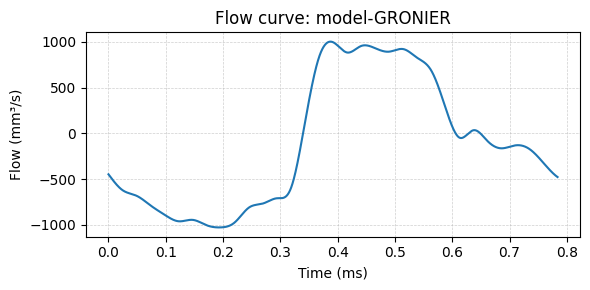

In [7]:
# =========================
# Visualize flow curve
# =========================

plt.figure(figsize=(6, 3))
plt.plot(global_t_interp, global_flow_interp, linewidth=1.5)
plt.xlabel('Time (ms)')
plt.ylabel('Flow (mm³/s)')
plt.title(f"Flow curve: {cfg['common'].get('sample_id', 'sample')}")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()


Displaying frame 16 / 31


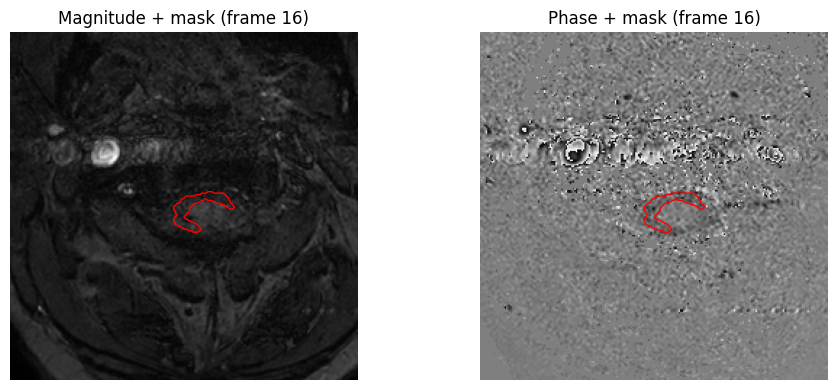

In [8]:
# =========================
# Visualize overlays: magnitude + mask, phase + mask
# =========================

# Choose a time frame to display (default: middle frame)
T = global_phase_full01.shape[0]
frame_idx = T // 2  # you can change this index and re-run the cell

print(f'Displaying frame {frame_idx} / {T-1}')

# Base images
if global_mag_full01.size > 0:
    base_mag = global_mag_full01[frame_idx]
else:
    base_mag = global_phase_full01[frame_idx]

base_phase = global_phase_full01[frame_idx]
mask2d = global_mask_full

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_overlay(base_mag, mask2d, f'Magnitude + mask (frame {frame_idx})')

plt.subplot(1, 2, 2)
plot_overlay(base_phase, mask2d, f'Phase + mask (frame {frame_idx})')

plt.tight_layout()
plt.show()


### Notes

- To visualize a **different time frame**, change `frame_idx` in the previous cell and re-run it.
- You can also inspect `global_mag_full01` / `global_phase_full01` directly (e.g., `global_phase_full01.shape`).

If something crashes:
- Verify that `CONFIG_PATH` is pointing to the correct YAML file.
- Check that the checkpoint path in `cfg['model']['checkpoint']` exists.
- Make sure `dicomdir` in the config points to a valid DICOMDIR directory.
